In [24]:
import concept_generalization
from concept_generalization import *
importlib.reload(concept_generalization)
from concept_generalization import *

In [25]:
center_list = [[0,0,0], [0,0,1], [0,1,0], [1,0,0]]
var_list = [ [[0.01, 0, 0], [0, 0.01, 0], [0, 0, 0.01] ]]*4
test_centers = [[0,0,0], [0,0,1], [0,1,0], [1,0,0], [0,1,1], [1,0,1], [1,1,0], [1,1,1]]
test_vars = [ [[0.001, 0, 0], [0, 0.001, 0], [0, 0, 0.001] ]]*8
# hidd_list = [128, 256, 512, 1024, 2048]
hidd_list = [128, 2048]
n_hiddDim = len(hidd_list)
n_test = 20


k, lo, hi, step = 10, 100, 110, 10
loss_n = range(lo, hi, step)

In [26]:
eval_list = [[] for _ in range(n_hiddDim)]  # list of test evaluations
losses_list = [[] for _ in range(n_hiddDim)]    # list of training loss histories
test_points_list = [[] for _ in range(n_hiddDim)]    # list of test points
weights_list = [[] for _ in range(n_hiddDim)]   # list of learned model weights
norms_list = [[] for _ in range(n_hiddDim)]     # list of norms of learned model weights

In [27]:
hidden_dim, activation_type = [hidd_list[0]], 'ReLU'
evals, test_points, losses, weights, norms = collect_clusterPredictions(hidden_dim, activation_type, center_list, var_list, test_centers, test_vars, n_test=n_test, k=k, lo=lo, hi=hi, step=step, use_tol=False, debug=True)
eval_list[0] = evals
losses_list[0] = losses
test_points_list[0] = test_points
weights_list[0] = weights
norms_list[0] = norms

on iteration 0  of k= 10
on iteration 1  of k= 10
on iteration 2  of k= 10
on iteration 3  of k= 10
on iteration 4  of k= 10
on iteration 5  of k= 10
on iteration 6  of k= 10
on iteration 7  of k= 10
on iteration 8  of k= 10
on iteration 9  of k= 10


In [28]:
hidden_dim, activation_type = [hidd_list[1]], 'ReLU'
evals, test_points, losses, weights, norms = collect_clusterPredictions(hidden_dim, activation_type, center_list, var_list, test_centers, test_vars, n_test=n_test, k=k, lo=lo, hi=hi, use_tol=False, debug=True, step=step)
eval_list[1] = evals
losses_list[1] = losses
test_points_list[1] = test_points
weights_list[1] = weights
norms_list[1] = norms

on iteration 0  of k= 10
on iteration 1  of k= 10
on iteration 2  of k= 10
on iteration 3  of k= 10
on iteration 4  of k= 10
on iteration 5  of k= 10
on iteration 6  of k= 10
on iteration 7  of k= 10
on iteration 8  of k= 10
on iteration 9  of k= 10


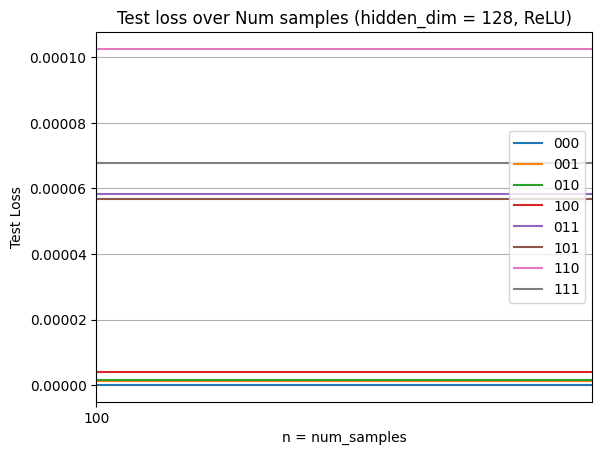

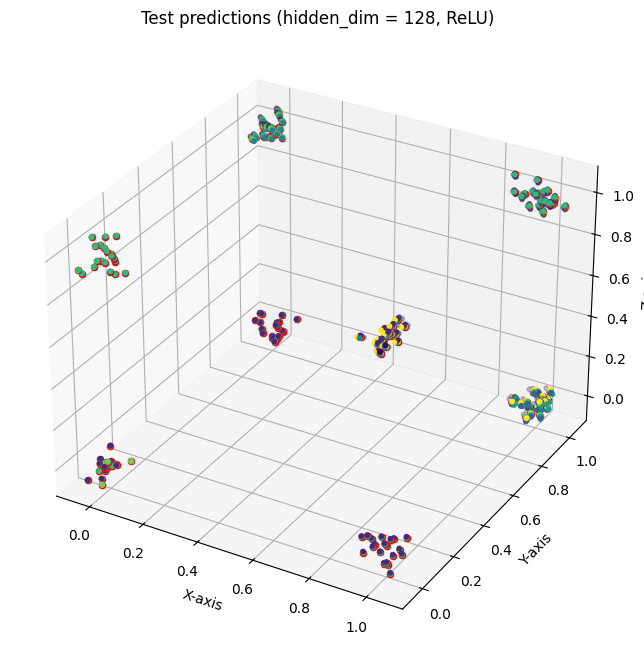

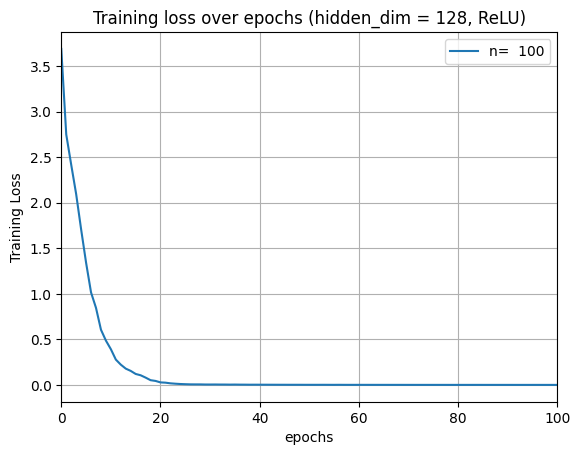

4.4531240916967363e-07 2.9092471010017107e-07


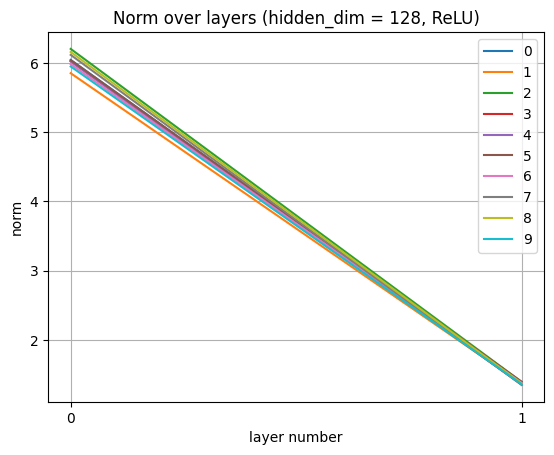

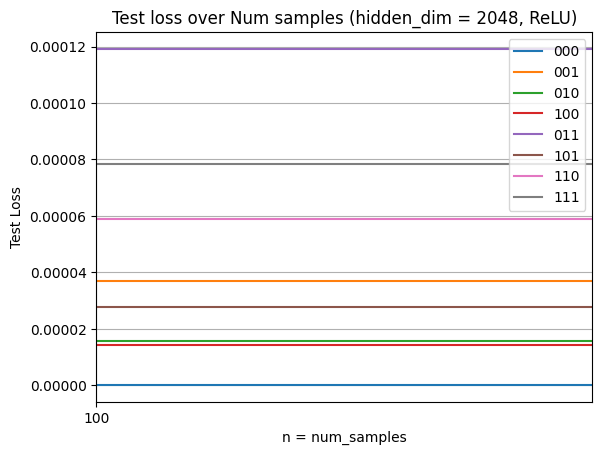

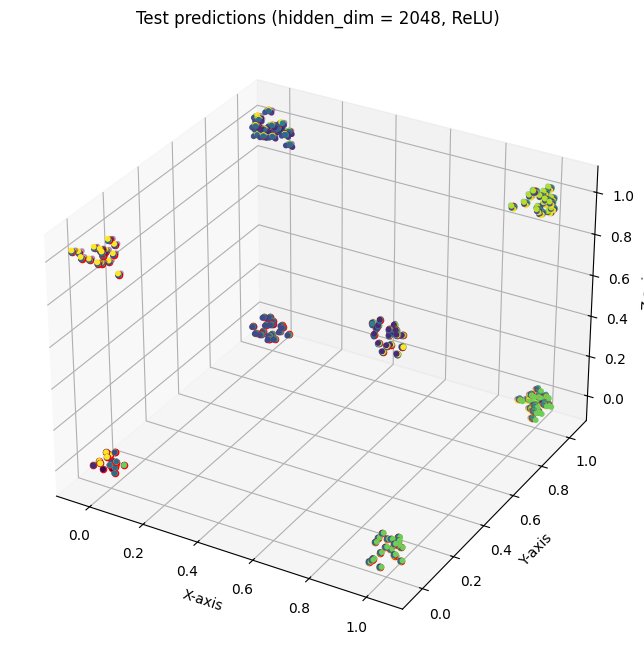

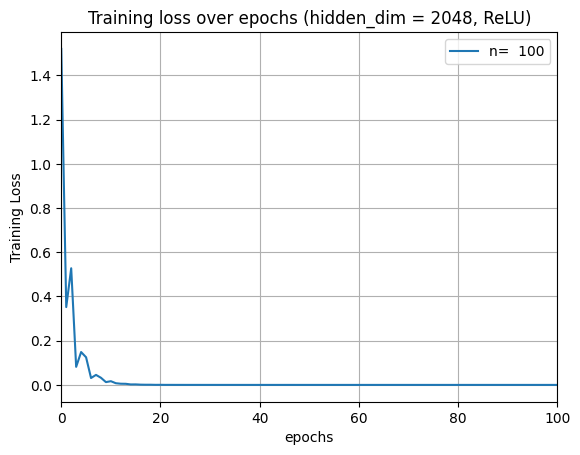

4.4531240916967363e-07 2.9092471010017107e-07


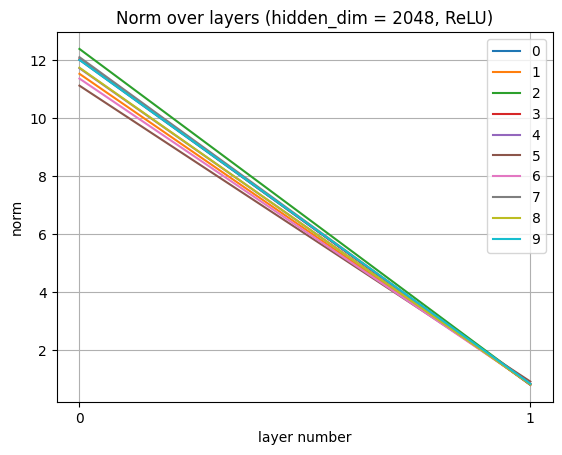

In [29]:
testLoss_list = [[] for _ in range(n_hiddDim)]

for i in range(n_hiddDim):
    hidden_dim = hidd_list[i]
    testLoss = compute_clusterLoss(eval_list[i], test_points_list[i], test_centers, n_test)
    plot_clusterTestLoss(np.concatenate((testLoss, testLoss), axis=1), test_centers, hidden_dim, activation_type, lo, hi, step, labels=10)
    testLoss_list[i] = np.reshape(testLoss, (8))
    
    scatter_testPredictions(eval_list[i],test_points_list[i], hidden_dim, test_ids=range(8), n_test=n_test, activation_type = activation_type, k=k)
    
    plot_list = range(len(loss_n))
    plot_trainingLoss(losses_list[i], loss_n, plot_list, hidden_dim, activation_type, k, epochs=100)
    print(losses_list[0][0][0][-2], losses_list[0][0][0][-1])

    plot_norms(norms_list[i], hidden_dim)


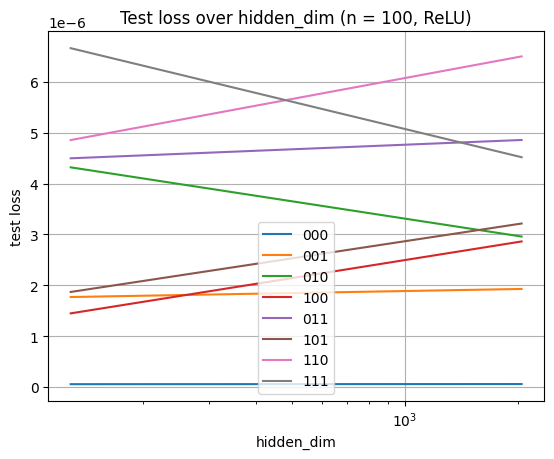

In [10]:
plot_hiddDim(np.array(testLoss_list), test_centers, hidd_list, lo=100)